# MiniBatchKMeans — Clustering à grande échelle (~2M profils)

Ce notebook applique **MiniBatchKMeans** sur l'ensemble des profils Twitter (~1,8–2 millions), **à l'exclusion des 420 profils labellisés** qui serviront de sonde de validation externe.

**Architecture du pipeline :**
```
Profils non labellisés  →  StandardScaler (partial_fit)  →  MiniBatchKMeans (partial_fit)
                                                                         ↓
420 profils labellisés  →  même StandardScaler (déjà fitté)  →  prédiction de cluster
```

Cette procédure garantit l'**absence de fuite de données** (data leakage) entre l'entraînement non-supervisé et l'évaluation.

## 1. Imports

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

sys.path.insert(0, str(Path.cwd().parents[2]))
from src.ml.features import get_labeled_features, get_user_features, ensure_user_features
from src.db import get_db_connection

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## 2. Configuration

In [2]:
ALL_FEATURES = [
    "verified", "default_profile", "default_profile_image",
    "tweet_count", "urls_per_tweet", "hashtags_per_tweet", "mentions_per_tweet",
    "retweet_rate", "reply_rate", "unique_sources", "bot_source_ratio",
    "followers_friends_ratio", "reputation", "favourites_per_status",
    "listed_per_follower", "account_age_days", "days_since_last_tweet",
    "observation_span_days", "tweet_frequency", "tweets_per_day_in_dataset",
    "description_length", "has_description", "has_url", "has_location",
    "screen_name_length", "screen_name_has_digits",
]

LOG_FEATURES = [
    "tweet_count", "account_age_days", "days_since_last_tweet",
    "observation_span_days", "description_length", "screen_name_length",
]

# Paramètres de streaming
BATCH_SIZE = 50_000     # profils par batch depuis PostgreSQL
K_CLUSTERS = 2          # nombre de clusters (tester aussi 3, 4)
RANDOM_STATE = 42

print(f"Features : {len(ALL_FEATURES)}")
print(f"Batch size : {BATCH_SIZE:,}")
print(f"K : {K_CLUSTERS}")

Features : 26
Batch size : 50,000
K : 2


## 3. Récupération des 420 profils labellisés (sondes)

In [3]:
data_path = Path.cwd().parents[2] / "data" / "processed" / "labeling_sample.csv"
df_labeled = get_labeled_features(str(data_path))
labeled_user_ids = df_labeled["user_id"].to_list()

# Extraction des features + log-transform
X_labeled = df_labeled.select(ALL_FEATURES).to_pandas().astype(float)
for col in LOG_FEATURES:
    X_labeled[col] = np.log1p(np.maximum(X_labeled[col], 0))

X_labeled = X_labeled.replace([np.inf, -np.inf], np.nan)
X_labeled = X_labeled.fillna(X_labeled.median(numeric_only=True)).fillna(0)

y_labeled = df_labeled["label"].to_pandas()

print(f"Profils labellisés : {len(labeled_user_ids)}")
print(f"User IDs à exclure du clustering : {len(labeled_user_ids)}")
print(f"  Exemple : {labeled_user_ids[:5]}")

Profils labellisés : 420
User IDs à exclure du clustering : 420
  Exemple : [965652865447587840, 1004414366777823232, 995510144317493248, 927198378194296835, 3317656799]


## 4. Streaming depuis PostgreSQL + entraînement incrémental

On récupère les profils par batchs, en excluant les 420 labellisés via `NOT IN`.

**Deux passes nécessaires :**
1. **Première passe** : `StandardScaler.partial_fit()` pour apprendre mean/std sur toute la population
2. **Deuxième passe** : `MiniBatchKMeans.partial_fit()` sur les données standardisées

In [4]:
# ---------------------------------------------------------------------------
# Passe 1 : StandardScaler.partial_fit sur tous les profils non labellisés
# ---------------------------------------------------------------------------

ensure_user_features()

scaler = StandardScaler()
total_profiles = 0

query = f"""
    SELECT {', '.join(ALL_FEATURES)}
    FROM user_features
    WHERE user_id NOT IN %s
    ORDER BY user_id
"""

with get_db_connection() as conn:
    with conn.cursor() as cur:
        cur.execute(query, (tuple(labeled_user_ids),))
        
        while True:
            rows = cur.fetchmany(BATCH_SIZE)
            if not rows:
                break
            
            batch = pl.DataFrame(rows, schema=ALL_FEATURES, orient="row").to_pandas().astype(float)
            for col in LOG_FEATURES:
                batch[col] = np.log1p(np.maximum(batch[col], 0))
            
            batch = batch.replace([np.inf, -np.inf], np.nan)
            batch = batch.fillna(batch.median(numeric_only=True)).fillna(0)
            
            scaler.partial_fit(batch.values)
            total_profiles += len(batch)
            
            if total_profiles % 200_000 == 0:
                print(f"  Scaler fit : {total_profiles:,} profils traités")

print(f"\n✅ StandardScaler fitté sur {total_profiles:,} profils")

  Scaler fit : 200,000 profils traités
  Scaler fit : 400,000 profils traités
  Scaler fit : 600,000 profils traités
  Scaler fit : 800,000 profils traités
  Scaler fit : 1,000,000 profils traités
  Scaler fit : 1,200,000 profils traités
  Scaler fit : 1,400,000 profils traités
  Scaler fit : 1,600,000 profils traités
  Scaler fit : 1,800,000 profils traités

✅ StandardScaler fitté sur 1,820,857 profils


In [5]:
# ---------------------------------------------------------------------------
# Passe 2 : MiniBatchKMeans.partial_fit sur les données standardisées
# ---------------------------------------------------------------------------

kmeans = MiniBatchKMeans(
    n_clusters=K_CLUSTERS,
    batch_size=min(1000, BATCH_SIZE),
    random_state=RANDOM_STATE,
    n_init=3,
    max_iter=100,
 )

total_profiles = 0

with get_db_connection() as conn:
    with conn.cursor() as cur:
        cur.execute(query, (tuple(labeled_user_ids),))
        
        while True:
            rows = cur.fetchmany(BATCH_SIZE)
            if not rows:
                break
            
            batch = pl.DataFrame(rows, schema=ALL_FEATURES, orient="row").to_pandas().astype(float)
            for col in LOG_FEATURES:
                batch[col] = np.log1p(np.maximum(batch[col], 0))
            
            batch = batch.replace([np.inf, -np.inf], np.nan)
            batch = batch.fillna(batch.median(numeric_only=True)).fillna(0)
            
            X_batch = scaler.transform(batch.values)
            kmeans.partial_fit(X_batch)
            total_profiles += len(batch)
            
            if total_profiles % 200_000 == 0:
                print(f"  KMeans fit : {total_profiles:,} profils traités")

print(f"\n✅ MiniBatchKMeans fitté sur {total_profiles:,} profils")
print(f"   Inertie : {kmeans.inertia_:.2e}")
print(f"   Centroïdes shape : {kmeans.cluster_centers_.shape}")

  KMeans fit : 200,000 profils traités
  KMeans fit : 400,000 profils traités
  KMeans fit : 600,000 profils traités
  KMeans fit : 800,000 profils traités
  KMeans fit : 1,000,000 profils traités
  KMeans fit : 1,200,000 profils traités
  KMeans fit : 1,400,000 profils traités
  KMeans fit : 1,600,000 profils traités
  KMeans fit : 1,800,000 profils traités

✅ MiniBatchKMeans fitté sur 1,820,857 profils
   Inertie : 2.65e+06
   Centroïdes shape : (2, 26)


## 5. Analyse des centroïdes

In [6]:
# Les centroïdes sont dans l'espace standardisé. On les inverse pour interprétation.
centroids_scaled = kmeans.cluster_centers_
centroids_raw = scaler.inverse_transform(centroids_scaled)

centroids_df = pl.DataFrame(
    centroids_raw,
    schema=ALL_FEATURES,
).with_columns(pl.lit(np.arange(K_CLUSTERS)).alias("cluster"))

print("=== Centroïdes (valeurs originales, log inversé approx) ===")
for c in range(K_CLUSTERS):
    print(f"\n--- Cluster {c} ---")
    row = centroids_df.filter(pl.col("cluster") == c).to_dicts()[0]
    # Top features les plus élevées pour ce cluster
    sorted_feats = sorted(
        [(k, v) for k, v in row.items() if k != "cluster"],
        key=lambda x: abs(x[1]),
        reverse=True,
    )
    for feat, val in sorted_feats[:8]:
        print(f"  {feat:30s} : {val:10.3f}")

=== Centroïdes (valeurs originales, log inversé approx) ===

--- Cluster 0 ---
  followers_friends_ratio        :    157.745
  account_age_days               :      7.240
  description_length             :      3.881
  tweets_per_day_in_dataset      :      2.871
  screen_name_length             :      2.429
  favourites_per_status          :      1.615
  hashtags_per_tweet             :      1.484
  tweet_count                    :      1.263

--- Cluster 1 ---
  account_age_days               :      6.930
  followers_friends_ratio        :      6.030
  description_length             :      2.941
  screen_name_length             :      2.447
  favourites_per_status          :      2.149
  hashtags_per_tweet             :      1.590
  tweets_per_day_in_dataset      :      1.407
  mentions_per_tweet             :      1.179


## 6. Projection des 420 sondes labellisées

Les 420 profils labellisés sont transformés avec le **scaler déjà fitté** sur les 2M, puis leur cluster est prédit par le **K-means déjà fitté**.

In [7]:
X_labeled_scaled = scaler.transform(X_labeled.values)
labels_labeled = kmeans.predict(X_labeled_scaled)

# Distribution des clusters pour les 420 profils
probe_dist = dict(zip(*np.unique(labels_labeled, return_counts=True)))
print("Distribution des clusters (420 sondes) :")
for c, n in sorted(probe_dist.items()):
    print(f"  Cluster {c} : {n} profils ({n/len(labels_labeled)*100:.1f}%)")

# Tableau croisé : cluster K-means vs label réel
cross = pl.DataFrame({
    "kmeans_cluster": labels_labeled,
    "true_label": y_labeled,
}).group_by(["kmeans_cluster", "true_label"]).len().sort(["kmeans_cluster", "true_label"])

print("\n=== Tableau croisé K-means vs Labels ===")
print(cross)

# Pureté par cluster
print("\n=== Pureté par cluster ===")
for c in sorted(set(labels_labeled)):
    mask = labels_labeled == c
    bot_rate = y_labeled[mask].mean()
    total = mask.sum()
    print(f"  Cluster {c} : {bot_rate*100:.1f}% bots ({int(y_labeled[mask].sum())}/{total})")

Distribution des clusters (420 sondes) :
  Cluster 0 : 265 profils (63.1%)
  Cluster 1 : 155 profils (36.9%)

=== Tableau croisé K-means vs Labels ===
shape: (4, 3)
┌────────────────┬────────────┬─────┐
│ kmeans_cluster ┆ true_label ┆ len │
│ ---            ┆ ---        ┆ --- │
│ i32            ┆ i8         ┆ u32 │
╞════════════════╪════════════╪═════╡
│ 0              ┆ 0          ┆ 254 │
│ 0              ┆ 1          ┆ 11  │
│ 1              ┆ 0          ┆ 94  │
│ 1              ┆ 1          ┆ 61  │
└────────────────┴────────────┴─────┘

=== Pureté par cluster ===
  Cluster 0 : 4.2% bots (11/265)
  Cluster 1 : 39.4% bots (61/155)


## 7. Visualisation (PCA sur les sondes)

La PCA est calculée sur les 420 sondes uniquement (à des fins de visualisation), les clusters étant ceux du K-means entraîné sur 2M.

C:\Users\Rodri\AppData\Local\Temp\ipykernel_29496\428405425.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", K_CLUSTERS)


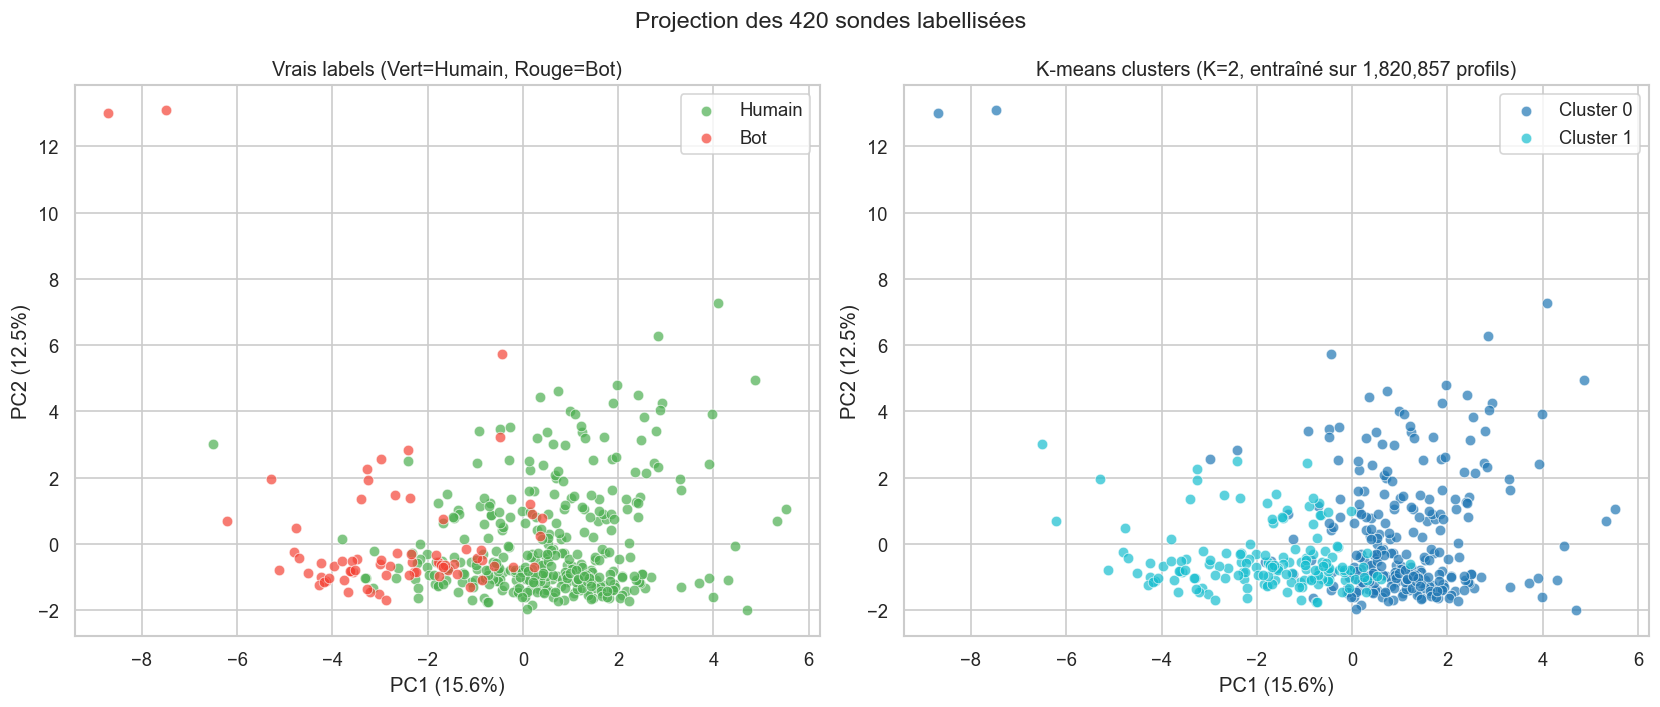

In [ ]:
pca = PCA(n_components=2)
X_labeled_pca = pca.fit_transform(X_labeled_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 : vrais labels
mask_human = y_labeled == 0
mask_bot = y_labeled == 1

axes[0].scatter(X_labeled_pca[mask_human, 0], X_labeled_pca[mask_human, 1],
                c="#4caf50", alpha=0.7, s=40, edgecolor="white", linewidth=0.5, label="Humain")
axes[0].scatter(X_labeled_pca[mask_bot, 0], X_labeled_pca[mask_bot, 1],
                c="#f44336", alpha=0.7, s=40, edgecolor="white", linewidth=0.5, label="Bot")
axes[0].legend()
axes[0].set_title("Vrais labels")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# Plot 2 : clusters K-means
cmap = plt.cm.get_cmap("tab10", K_CLUSTERS)
for c in range(K_CLUSTERS):
    mask = labels_labeled == c
    axes[1].scatter(
        X_labeled_pca[mask, 0], X_labeled_pca[mask, 1],
        c=[cmap(c)], alpha=0.7, s=40,
        edgecolor="white", linewidth=0.5,
        label=f"Cluster {c}",
    )
axes[1].legend()
axes[1].set_title(f"K-means clusters (K={K_CLUSTERS}, entraîné sur {total_profiles:,} profils)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.suptitle("Projection des 420 sondes labellisées", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Méthode du coude (sur un sous-échantillon)

Pour valider le choix de K=3, on calcule l'inertie pour différents K sur un sous-échantillon de 100 000 profils.

  K=2 → inertie = 2.49e+06
  K=3 → inertie = 2.41e+06
  K=4 → inertie = 2.26e+06
  K=5 → inertie = 2.18e+06
  K=6 → inertie = 2.10e+06
  K=7 → inertie = 1.96e+06


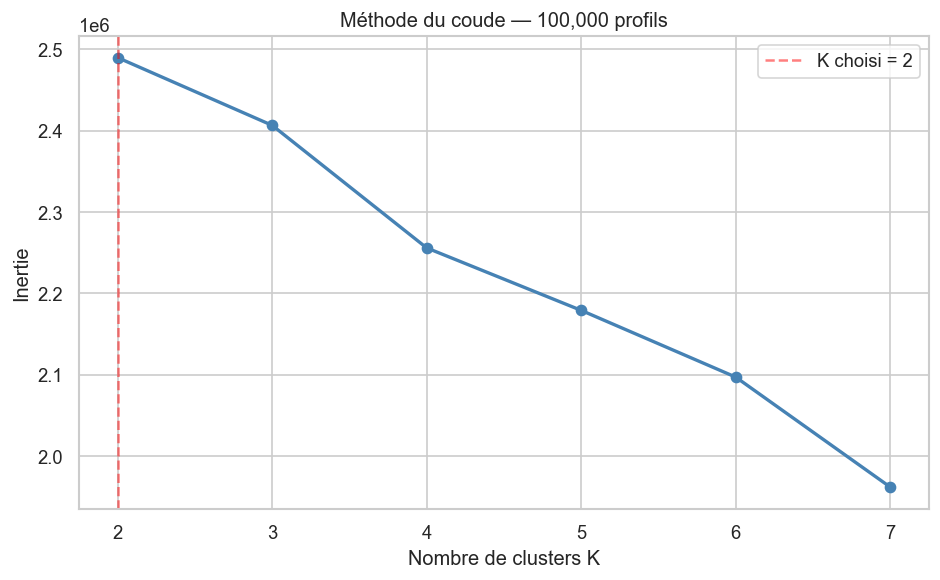

In [9]:
N_SUBSAMPLE = 100_000
K_RANGE = range(2, 8)

# Tirage d'un sous-échantillon aléatoire (seed fixe)
query_sub = f"""
    SELECT {', '.join(ALL_FEATURES)}
    FROM user_features
    WHERE user_id NOT IN %s
    ORDER BY MD5(user_id::text || 'elbow')
    LIMIT {N_SUBSAMPLE}
"""

with get_db_connection() as conn:
    with conn.cursor() as cur:
        cur.execute(query_sub, (tuple(labeled_user_ids),))
        rows = cur.fetchall()

subsample = pl.DataFrame(rows, schema=ALL_FEATURES, orient="row").to_pandas().astype(float)
for col in LOG_FEATURES:
    subsample[col] = np.log1p(np.maximum(subsample[col], 0))

subsample = subsample.replace([np.inf, -np.inf], np.nan)
subsample = subsample.fillna(subsample.median(numeric_only=True)).fillna(0)

X_sub = scaler.transform(subsample.values)

inertias = []
for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, batch_size=1000, random_state=RANDOM_STATE, n_init=3)
    km.fit(X_sub)
    inertias.append(km.inertia_)
    print(f"  K={k} → inertie = {km.inertia_:.2e}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), inertias, marker="o", color="steelblue", linewidth=2)
ax.axvline(K_CLUSTERS, color="red", linestyle="--", alpha=0.5, label=f"K choisi = {K_CLUSTERS}")
ax.set_xlabel("Nombre de clusters K")
ax.set_ylabel("Inertie")
ax.set_title(f"Méthode du coude — {N_SUBSAMPLE:,} profils")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Export des prédictions pour comparaison croisée

In [10]:
# DataFrame : user_id + features + true_label + kmeans_cluster
results_df = df_labeled.select(["user_id"] + ALL_FEATURES + ["label"]).to_pandas()
results_df["kmeans_cluster"] = labels_labeled

# Sauvegarde
output_path = Path("../../data/processed/kmeans_2m_probe_predictions.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)
print(f"✅ Prédictions exportées vers {output_path}")

# Aperçu
print("\nAperçu :")
print(results_df[["user_id", "label", "kmeans_cluster"]].head(10))

✅ Prédictions exportées vers ..\..\data\processed\kmeans_2m_probe_predictions.csv

Aperçu :
               user_id  label  kmeans_cluster
0   965652865447587840      1               0
1  1004414366777823232      1               1
2   995510144317493248      1               1
3   927198378194296835      1               1
4           3317656799      1               0
5   822517413732229120      1               1
6  1007080862436020225      0               1
7           3546758548      0               1
8           1472225126      0               0
9  1005225453446148098      1               1


## 10. Synthèse

| Aspect | Détail |
|--------|--------|
| **Dataset d'entraînement** | ~2M profils (tous sauf les 420 labellisés) |
| **Prétraitement** | Log-transform + StandardScaler (partial_fit) |
| **Algorithme** | MiniBatchKMeans (K=3) |
| **Mémoire** | Constante (streaming par batchs de 50k) |
| **Validation** | Projection des 420 sondes comme données externes |

**Questions à discuter dans le rapport :**
- Les bots labellisés sont-ils sur-représentés dans un cluster spécifique ?
- La pureté des clusters est-elle meilleure que celle obtenue sur les 420 seuls ?
- L'entraînement sur 2M change-t-il la structure des clusters par rapport à un K-means sur 420 ?
- Comparaison avec HDBSCAN et Spectral (via ARI croisé dans `comparison_420.ipynb`).